In [1]:
# Go up one level to the project root (assuming your notebook is in /src)
%cd ..
%cd ..

# Verify you are in the right place
import os
print(f"Current working directory: {os.getcwd()}")

/home/lyngsberg/bachelor_project/src
/home/lyngsberg/bachelor_project
Current working directory: /home/lyngsberg/bachelor_project


In [2]:
from pathlib import Path
from vedo import Volume
import numpy as np
import matplotlib.pyplot as plt

# 1. Safely construct the file path
BASE_DATA_PATH = Path("data/raw/bugNIST_900")
data_file = "GH/gras_9_043.tif"
full_path = BASE_DATA_PATH / data_file

if not full_path.exists():
    print(f"Error: Could not find file at {full_path.absolute()}")
    exit()

print(f"Loading volume: {full_path.name}...\n")
vol = Volume(str(full_path))

Loading volume: gras_9_043.tif...



In [3]:

print("=== 3D Volume Statistics ===")

# 1. Dimensions (How many pixels/voxels in X, Y, Z)
dims = vol.dimensions()
print(f"Voxel Dimensions : {dims[0]} x {dims[1]} x {dims[2]}")
print(f"Total Voxels     : {dims[0] * dims[1] * dims[2]:,}")

# 2. Physical Bounds (The 3D bounding box coordinates)
bounds = vol.bounds()
print(f"\nPhysical Bounds  :")
print(f"  X-axis: {bounds[0]:.1f} to {bounds[1]:.1f}")
print(f"  Y-axis: {bounds[2]:.1f} to {bounds[3]:.1f}")
print(f"  Z-axis: {bounds[4]:.1f} to {bounds[5]:.1f}")

# 3. Intensity Range (Useful for setting thresholds or colormaps)
s_range = vol.scalar_range()
print(f"\nIntensity Range  : Min {s_range[0]}  |  Max {s_range[1]}")

print("\n=== Data Science Bridge ===")
# 4. Extracting the raw NumPy array
# This is how you bridge vedo visualization with pandas, scikit-learn, etc.
np_data = vol.tonumpy()

print(f"NumPy Shape      : {np_data.shape} (Note: often Z, Y, X order)")
print(f"Data Type        : {np_data.dtype}")
print(f"Mean Intensity   : {np.mean(np_data):.2f}")
print(f"Median Intensity : {np.median(np_data):.2f}")

=== 3D Volume Statistics ===
Voxel Dimensions : 450 x 450 x 900
Total Voxels     : 182,250,000

Physical Bounds  :
  X-axis: 0.0 to 449.0
  Y-axis: 0.0 to 449.0
  Z-axis: 0.0 to 899.0

Intensity Range  : Min 0.0  |  Max 234.0

=== Data Science Bridge ===
NumPy Shape      : (450, 450, 900) (Note: often Z, Y, X order)
Data Type        : uint8
Mean Intensity   : 6.02
Median Intensity : 0.00


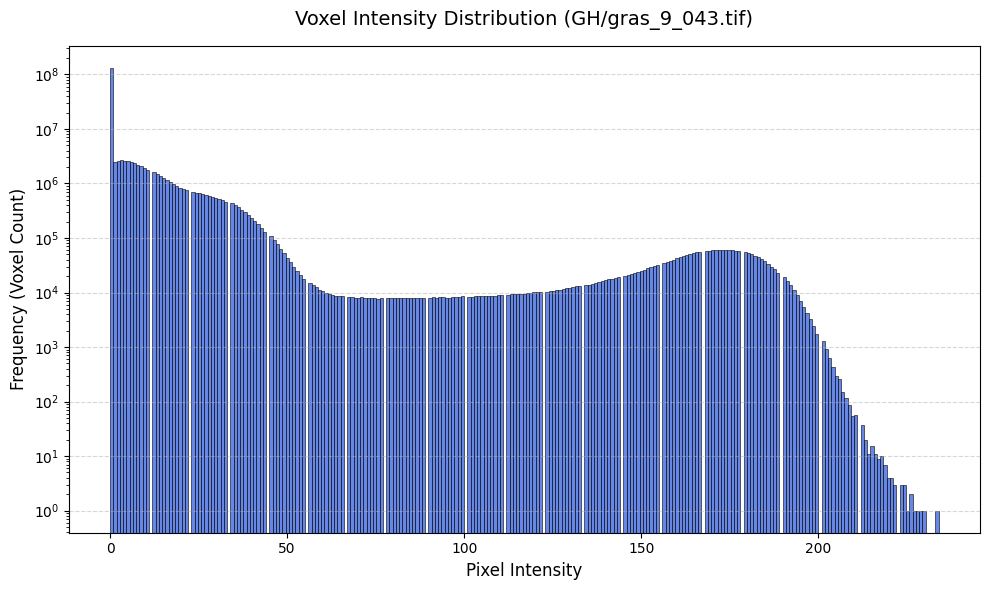

In [5]:
# 1. Flatten the 3D volume into a 1D array
# Matplotlib's hist() needs a flat list of numbers, not a 3D grid
flat_data = np_data.flatten()

# 2. Set up the plot aesthetics
plt.figure(figsize=(10, 6))

# 3. Plot the histogram
# 'bins=100' is a solid starting point. If your TIFF is 16-bit (values up to 65535), 
# you might want to increase this to 256 or 512 for finer detail.
n, bins, patches = plt.hist(flat_data, bins=255, color='royalblue', alpha=0.8, edgecolor='black', linewidth=0.5)

# 4. Add labels and title
plt.title(f"Voxel Intensity Distribution ({data_file})", fontsize=14, pad=15)
plt.xlabel("Pixel Intensity", fontsize=12)
plt.ylabel("Frequency (Voxel Count)", fontsize=12)

# Pro-Tip for Volumetric Scans: 
# If your scan has a lot of empty space, the background (usually 0) will create a massive spike, 
# making the rest of the data hard to see. Uncomment the line below to use a logarithmic scale.
plt.yscale('log') 

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Display the plot in the notebook
plt.savefig("figures/otsu.png")
plt.show()


In [ ]:
# Checking view sizes
from PIL import Image
import os

img_path = "/home/lyngsberg/bachelor_project/data/processed/GH/gras_9_042/view_000.png"

with Image.open(img_path) as img:
    width, height = img.size
    print(f"Dimensions: {width}x{height}")
    print(f"Format: {img.format}") # This will tell you if it's actually a JPEG, PNG, etc.

Dimensions: 251x500
Format: PNG


In [ ]:
import pickle
with open("data/processed/bugNIST_900/GH/gras_9_043/cameras.pkl", "rb") as f:
    cams = pickle.load(f)

for name in ["view_000"]:
    c = cams[name]
    print(f"\n{name}")
    print(f"  t          : {c['t']}")
    print(f"  vol_center : {c['vol_center']}")
    print(f"  volume_shape: {c['volume_shape']}")
    print(f"  sphere_radius: {c['sphere_radius']}")
    print(f"  az_deg: {c['az_deg']:.1f}  el_deg: {c['el_deg']:.1f}")


view_000
  t          : [ 449.77509114 1505.78998354 -570.93966573]
  vol_center : [225. 225. 450.]
  volume_shape: (450, 450, 900)
  sphere_radius: 1653.4055763786453
  az_deg: 80.0  el_deg: -38.1

view_001
  t          : [1688.80186436  925.1082863   763.69433351]
  vol_center : [225. 225. 450.]
  volume_shape: (450, 450, 900)
  sphere_radius: 1653.4055763786453
  az_deg: 25.6  el_deg: 11.0

view_003
  t          : [ -536.34791833   336.94900799 -1014.13098689]
  vol_center : [225. 225. 450.]
  volume_shape: (450, 450, 900)
  sphere_radius: 1653.4055763786453
  az_deg: 171.6  el_deg: -62.3
